# 🏠 Analyse Exploratoire du Marché Immobilier Marocain

**Objectif** : Explorer et analyser les données combinées (Avito + Mubawab) pour comprendre les tendances du marché immobilier au Maroc.

---

## 1. 📦 Imports & Configuration

In [1]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\ayoub\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import glob
import os

warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('✅ Imports chargés avec succès')

✅ Imports chargés avec succès


## 2. 📂 Chargement des Données

In [3]:
# Charger le fichier combiné le plus récent
data_dir = os.path.join('..', 'data', 'processed')
files = glob.glob(os.path.join(data_dir, 'immobilier_maroc*.csv'))

if not files:
    raise FileNotFoundError('❌ Aucun fichier combiné trouvé dans data/processed/')

latest_file = max(files, key=os.path.getctime)
print(f'📄 Fichier chargé : {latest_file}')

df = pd.read_csv(latest_file)
print(f'📊 {len(df)} annonces | {len(df.columns)} colonnes')
print(f'📅 Date scraping : {df["date_scraping"].unique()}')

📄 Fichier chargé : ..\data\processed\immobilier_maroc_20260321_160003.csv
📊 75 annonces | 20 colonnes
📅 Date scraping : ['2026-03-21' '2026-03-19']


## 3. 🔍 Aperçu des Données

In [4]:
# Premières lignes
df.head(10)

,id_annonce,source,type_bien,ville,prix,surface_m2,nb_chambres,nb_salles_bain,etage,parking,ascenseur,balcon,piscine,jardin,titre,description,url,date_scraping,prix_m2,score_equipements
0,Appartement_%C3%A0_vendre_Mhamid_9_57641654,Avito,Appartement,Marrakech,350000.0,60.0,2.0,1.0,4.0,0,1,0,0,0,Appartement à vendre Mhamid 9,Appartement à vendre au 4ème étage avec ascens...,https://www.avito.ma/fr/m_hamid/appartements/A...,2026-03-21,5833.33,1
1,Appartement_%C3%A0_vendre_57_m%C2%B2_%C3%A0_Ma...,Avito,Appartement,Marrakech,410000.0,NaN,2.0,1.0,2.0,0,0,0,0,0,Appartement à vendre 57 m² à Marrakech,Je mets en vente mon appartement en tres bon é...,https://www.avito.ma/fr/hay_massira/appartemen...,2026-03-21,NaN,0
2,Appartement_%C3%A0_vendre_Saada_55932125,Avito,Appartement,Marrakech,420000.0,52.0,2.0,1.0,2.0,0,1,0,0,0,Appartement à vendre Saada,Appartement à vendre 2 chambres salon salle de...,https://www.avito.ma/fr/es_saada/appartements/...,2026-03-21,8076.92,1
3,Appartement_%C3%A0_vendre_%C3%A0_Saada_pr%C3%A...,Avito,Appartement,Marrakech,475000.0,52.0,2.0,1.0,1.0,0,0,0,0,0,Appartement à vendre à Saada près Marjane,Appartement à vendre à Saada près Marjane \nBe...,https://www.avito.ma/fr/es_saada/appartements/...,2026-03-21,9134.62,0
4,__Appartement_%C3%A0_vendre_pr%C3%A8s_de_Marja...,Avito,Appartement,Marrakech,490000.0,56.0,2.0,1.0,3.0,0,1,0,0,0,😍Appartement à vendre près de Marjane,"⛳ Emplacement : Près de Marjane, route de Casa...",https://www.avito.ma/fr/route_de_casablanca/ap...,2026-03-21,8750.00,1
5,Appartement_meubl%C3%A9_%C3%A0_vendre_azzouzia...,Avito,Appartement,Marrakech,550000.0,NaN,2.0,1.0,1.0,0,1,0,0,0,Appartement meublé à vendre azzouzia bon état,"À vendre — Appartement meublé à Azzouzia, Marr...",https://www.avito.ma/fr/azzouzia/appartements/...,2026-03-21,NaN,1
6,Studio_%C3%A0_vendre_proche_centre_ville_57652471,Avito,Appartement,Marrakech,570000.0,54.0,2.0,1.0,5.0,1,1,0,1,0,Studio à vendre proche centre-ville,studio à vendre 54m 5eme étage avec ascenseur ...,https://www.avito.ma/fr/route_de_casablanca/ap...,2026-03-21,10555.56,3
7,Appartement_neuf_avec_terrasse___%C3%A0_vendre...,Avito,Appartement,Marrakech,580000.0,54.0,1.0,1.0,5.0,1,1,1,1,0,Appartement neuf avec terrasse😍 à vendre à Mar...,⛳ Emplacement : Route de Casablanca\n🏩 Superfi...,https://www.avito.ma/fr/route_de_casablanca/ap...,2026-03-21,10740.74,4
8,Studio_%C3%A0_vendre_avec_piscine_57468855,Avito,Appartement,Marrakech,630000.0,48.0,1.0,1.0,0.0,1,0,1,1,1,Studio à vendre avec piscine,Je vends un appart très bien situé proche du c...,https://www.avito.ma/fr/palmeraie/appartements...,2026-03-21,13125.00,4
9,Appartement_excellent_%C3%A0_vendre_%C3%A0_Hay...,Avito,Appartement,Marrakech,670000.0,58.0,2.0,2.0,1.0,0,1,0,0,0,Appartement excellent à vendre à Hay Charaf su...,Appartement excellent à vendre à Hay Charaf pr...,https://www.avito.ma/fr/hay_charaf/appartement...,2026-03-21,11551.72,1


In [5]:
df.tail()

,id_annonce,source,type_bien,ville,prix,surface_m2,nb_chambres,nb_salles_bain,etage,parking,ascenseur,balcon,piscine,jardin,titre,description,url,date_scraping,prix_m2,score_equipements
70,appartement,Mubawab,Appartement,Asilah,1370000.0,85.0,1.0,2.0,NaN,0,1,1,0,0,Appartement en vente à Asilah. 1 belle chambre...,Appartement avec vue panoramique sur mer à ven...,https://www.mubawab.ma/fr/a/8316761/appartemen...,2026-03-19,16117.65,2
71,appartement,Mubawab,Appartement,Casablanca,725000.0,33.0,1.0,2.0,NaN,1,1,1,1,1,Appartement à vendre à Anfa. Surface totale 33...,Appartement idéal à la vente. Prix 725 000 DH....,https://www.mubawab.ma/fr/pa/8230729/apparteme...,2026-03-19,21969.70,5
72,appartement,Mubawab,Appartement,Casablanca,1600000.0,124.0,3.0,2.0,1er,0,0,0,0,0,Appartement à vendre quartier Floride sidi Maa...,"Appartement haut standing double salon, 3 cham...",https://www.mubawab.ma/fr/a/8317173/appartemen...,2026-03-19,12903.23,0
73,appartement,Mubawab,Appartement,Mohammedia,2100000.0,135.0,3.0,2.0,3ème,1,1,1,0,0,Appartement El Mansouria luxe et confort,- Résidence renommée Les Belles Terrasses\n- A...,https://www.mubawab.ma/fr/a/8317322/appartemen...,2026-03-19,15555.56,3
74,appartement,Mubawab,Appartement,Tanger,3915000.0,124.0,3.0,NaN,NaN,0,0,0,0,0,Appartement en vente à View Tower. 3 chambres ...,"Un espace généreux avec 3 chambres lumineuses,...",https://www.mubawab.ma/fr/pa/7595991/apparteme...,2026-03-19,31572.58,0


In [6]:
# Informations sur les colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_annonce         75 non-null     object 
 1   source             75 non-null     object 
 2   type_bien          75 non-null     object 
 3   ville              75 non-null     object 
 4   prix               70 non-null     float64
 5   surface_m2         53 non-null     float64
 6   nb_chambres        75 non-null     float64
 7   nb_salles_bain     74 non-null     float64
 8   etage              69 non-null     object 
 9   parking            75 non-null     int64  
 10  ascenseur          75 non-null     int64  
 11  balcon             75 non-null     int64  
 12  piscine            75 non-null     int64  
 13  jardin             75 non-null     int64  
 14  titre              75 non-null     object 
 15  description        75 non-null     object 
 16  url                75 non-nu

In [7]:
# Statistiques descriptives
df.describe()

,prix,surface_m2,nb_chambres,nb_salles_bain,parking,ascenseur,balcon,piscine,jardin,prix_m2,score_equipements
count,7.000000e+01,53.000000,75.000000,74.000000,75.000000,75.000000,75.000000,75.000000,75.000000,48.000000,75.000000
mean,1.305679e+06,80.867925,1.853333,1.500000,0.426667,0.400000,0.413333,0.360000,0.200000,17013.388750,1.800000
std,6.879945e+05,33.346686,0.710792,0.624829,0.497924,0.493197,0.495748,0.483232,0.402694,7338.871351,1.479591
min,3.500000e+05,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5266.670000,0.000000
25%,8.075000e+05,55.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11356.097500,1.000000
50%,1.200000e+06,80.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15302.050000,2.000000
75%,1.587500e+06,100.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,23557.690000,3.000000
max,3.915000e+06,188.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35000.000000,5.000000


In [8]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_df[missing_df['Manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

,Manquantes,Pourcentage (%)
prix_m2,27,36.0
surface_m2,22,29.3
etage,6,8.0
prix,5,6.7
nb_salles_bain,1,1.3


## 4. 📊 KPIs Clés du Marché

In [9]:
# ==================================================
# KPIs PRINCIPAUX
# ==================================================

total_annonces = len(df)
prix_moyen = df['prix'].mean()
prix_median = df['prix'].median()
surface_moy = df['surface_m2'].mean()
prix_m2_moy = df['prix_m2'].mean() if 'prix_m2' in df.columns else None
nb_villes = df['ville'].nunique()
nb_sources = df['source'].nunique()

print('=' * 60)
print('🏠 KPIs MARCHÉ IMMOBILIER MAROCAIN')
print('=' * 60)
print(f'📊 Total annonces          : {total_annonces}')
print(f'💰 Prix moyen              : {prix_moyen:,.0f} MAD' if pd.notna(prix_moyen) else '💰 Prix moyen              : N/A')
print(f'💰 Prix médian             : {prix_median:,.0f} MAD' if pd.notna(prix_median) else '💰 Prix médian             : N/A')
print(f'📐 Surface moyenne         : {surface_moy:.0f} m²' if pd.notna(surface_moy) else '📐 Surface moyenne         : N/A')
print(f'💵 Prix moyen par m²       : {prix_m2_moy:,.0f} MAD/m²' if pd.notna(prix_m2_moy) else '💵 Prix moyen par m²       : N/A')
print(f'📍 Nombre de villes        : {nb_villes}')
print(f'🌐 Sources de données      : {nb_sources}')
print('=' * 60)

🏠 KPIs MARCHÉ IMMOBILIER MAROCAIN
📊 Total annonces          : 75
💰 Prix moyen              : 1,305,679 MAD
💰 Prix médian             : 1,200,000 MAD
📐 Surface moyenne         : 81 m²
💵 Prix moyen par m²       : 17,013 MAD/m²
📍 Nombre de villes        : 5
🌐 Sources de données      : 2


## 5. 📈 Analyse par Source

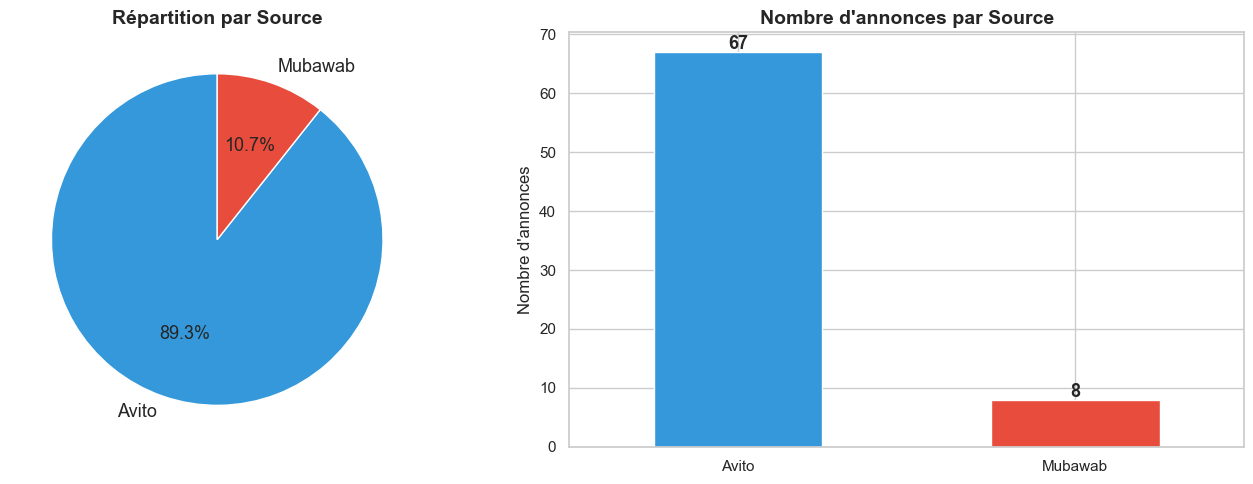


📊 Statistiques par source :


,Nb annonces,Prix moyen (MAD),Surface moy (m²)
source,,,
Avito,67,1269798.0,79.0
Mubawab,8,1583750.0,91.0


In [10]:
# Répartition par source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
source_counts = df['source'].value_counts()
colors = ['#3498db', '#e74c3c']
axes[0].pie(source_counts, labels=source_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Répartition par Source', fontsize=14, fontweight='bold')

# Bar chart avec stats
source_stats = df.groupby('source').agg(
    count=('id_annonce', 'count'),
    prix_moy=('prix', 'mean'),
    surface_moy=('surface_m2', 'mean')
).round(0)

source_stats['count'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Nombre d\'annonces par Source', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nombre d\'annonces')
axes[1].tick_params(axis='x', rotation=0)

for i, (idx, val) in enumerate(source_stats['count'].items()):
    axes[1].text(i, val + 0.5, str(int(val)), ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print('\n📊 Statistiques par source :')
source_stats.columns = ['Nb annonces', 'Prix moyen (MAD)', 'Surface moy (m²)']
source_stats

## 6. 📍 Analyse par Ville

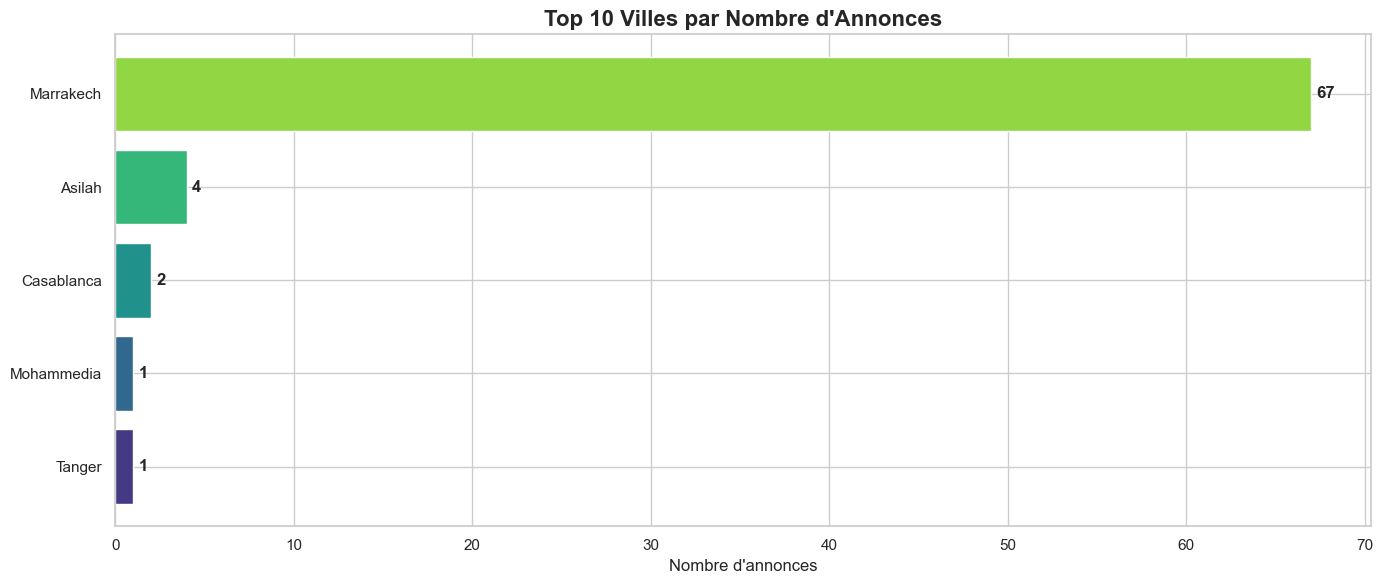

In [11]:
# Top villes par nombre d'annonces
ville_counts = df['ville'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(ville_counts.index[::-1], ville_counts.values[::-1], 
               color=sns.color_palette('viridis', len(ville_counts)))
ax.set_title('Top 10 Villes par Nombre d\'Annonces', fontsize=16, fontweight='bold')
ax.set_xlabel('Nombre d\'annonces')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Prix moyen par ville (si données prix disponibles)
df_with_prix = df[df['prix'].notna()]

if len(df_with_prix) > 0:
    ville_prix = df_with_prix.groupby('ville').agg(
        prix_moyen=('prix', 'mean'),
        prix_median=('prix', 'median'),
        nb_annonces=('id_annonce', 'count'),
        surface_moy=('surface_m2', 'mean')
    ).sort_values('prix_moyen', ascending=False)
    
    print('💰 Prix par ville :')
    display(ville_prix.round(0))
    
    # Visualisation
    if len(ville_prix) > 1:
        fig = px.bar(ville_prix.reset_index(), x='ville', y='prix_moyen',
                     color='nb_annonces', 
                     title='Prix Moyen par Ville',
                     labels={'prix_moyen': 'Prix Moyen (MAD)', 'ville': 'Ville', 'nb_annonces': 'Nb annonces'},
                     color_continuous_scale='viridis')
        fig.update_layout(xaxis_tickangle=45)
        fig.show()
else:
    print('⚠️ Aucune donnée de prix disponible')

💰 Prix par ville :


,prix_moyen,prix_median,nb_annonces,surface_moy
ville,,,,
Tanger,3915000.0,3915000.0,1,124.0
Mohammedia,2100000.0,2100000.0,1,135.0
Marrakech,1269798.0,1200000.0,62,78.0
Casablanca,1162500.0,1162500.0,2,78.0
Asilah,1082500.0,1115000.0,4,78.0


## 7. 🏗️ Analyse par Type de Bien

In [13]:
# Répartition par type de bien
type_counts = df['type_bien'].value_counts()

fig = px.pie(values=type_counts.values, names=type_counts.index,
             title='Répartition par Type de Bien',
             color_discrete_sequence=px.colors.qualitative.Set2,
             hole=0.35)
fig.update_traces(textinfo='label+percent+value')
fig.show()

In [14]:
# Stats par type de bien
type_stats = df.groupby('type_bien').agg(
    nb_annonces=('id_annonce', 'count'),
    prix_moyen=('prix', 'mean'),
    surface_moy=('surface_m2', 'mean'),
    prix_m2_moy=('prix_m2', 'mean')
).sort_values('nb_annonces', ascending=False).round(0)

type_stats.columns = ['Nb annonces', 'Prix moyen (MAD)', 'Surface moy (m²)', 'Prix/m² moy']
type_stats

,Nb annonces,Prix moyen (MAD),Surface moy (m²),Prix/m² moy
type_bien,,,,
Appartement,71,1321216.0,79.0,17376.0
Duplex,4,958667.0,114.0,8677.0


## 8. 💰 Analyse des Prix

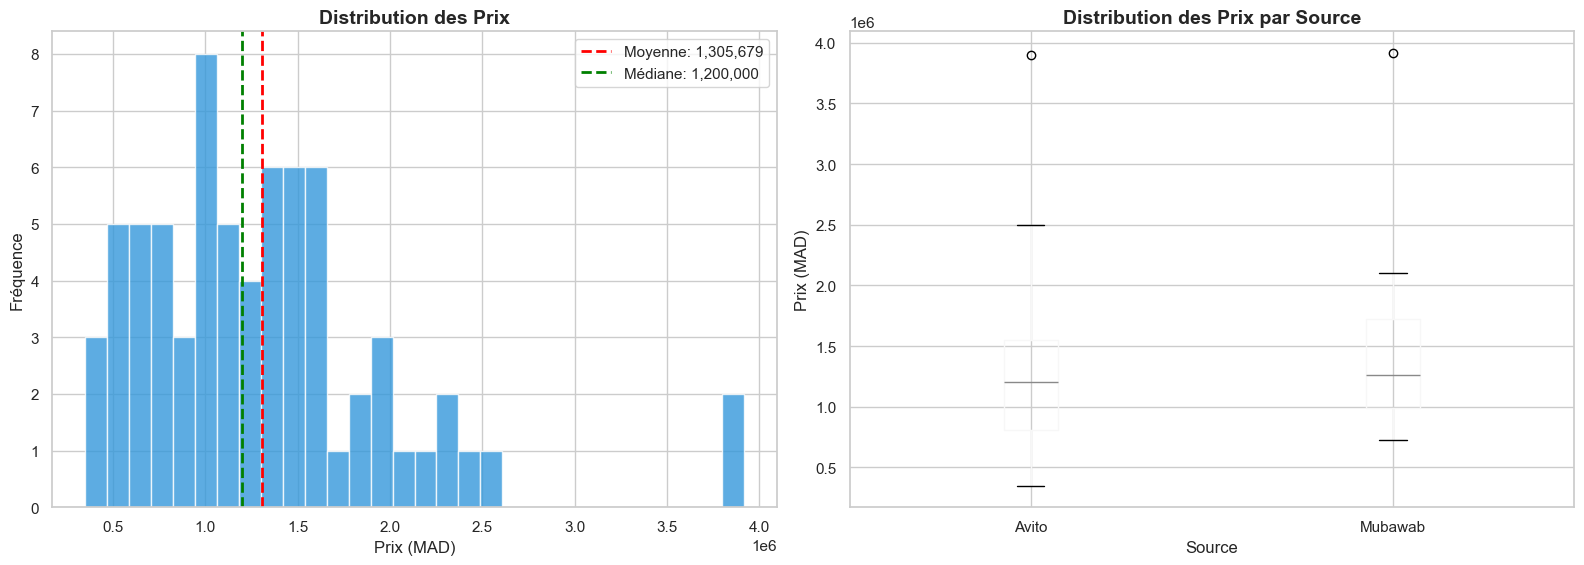

In [15]:
# Distribution des prix
df_prix = df[df['prix'].notna()].copy()

if len(df_prix) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogramme
    axes[0].hist(df_prix['prix'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0].axvline(df_prix['prix'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df_prix["prix"].mean():,.0f}')
    axes[0].axvline(df_prix['prix'].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {df_prix["prix"].median():,.0f}')
    axes[0].set_title('Distribution des Prix', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Prix (MAD)')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()
    
    # Box plot par source
    df_prix.boxplot(column='prix', by='source', ax=axes[1])
    axes[1].set_title('Distribution des Prix par Source', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Prix (MAD)')
    plt.suptitle('')  # Remove auto-generated title
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Aucune donnée de prix disponible pour cette visualisation')

In [16]:
# Prix par m² - Distribution
df_prixm2 = df[df['prix_m2'].notna()].copy()

if len(df_prixm2) > 0:
    fig = px.histogram(df_prixm2, x='prix_m2', nbins=25,
                       title='Distribution du Prix au m²',
                       labels={'prix_m2': 'Prix par m² (MAD)'},
                       color_discrete_sequence=['#2ecc71'])
    fig.add_vline(x=df_prixm2['prix_m2'].mean(), line_dash='dash', line_color='red',
                  annotation_text=f'Moyenne: {df_prixm2["prix_m2"].mean():,.0f} MAD/m²')
    fig.show()
else:
    print('⚠️ Aucune donnée prix/m² disponible')

## 9. 📐 Analyse des Surfaces

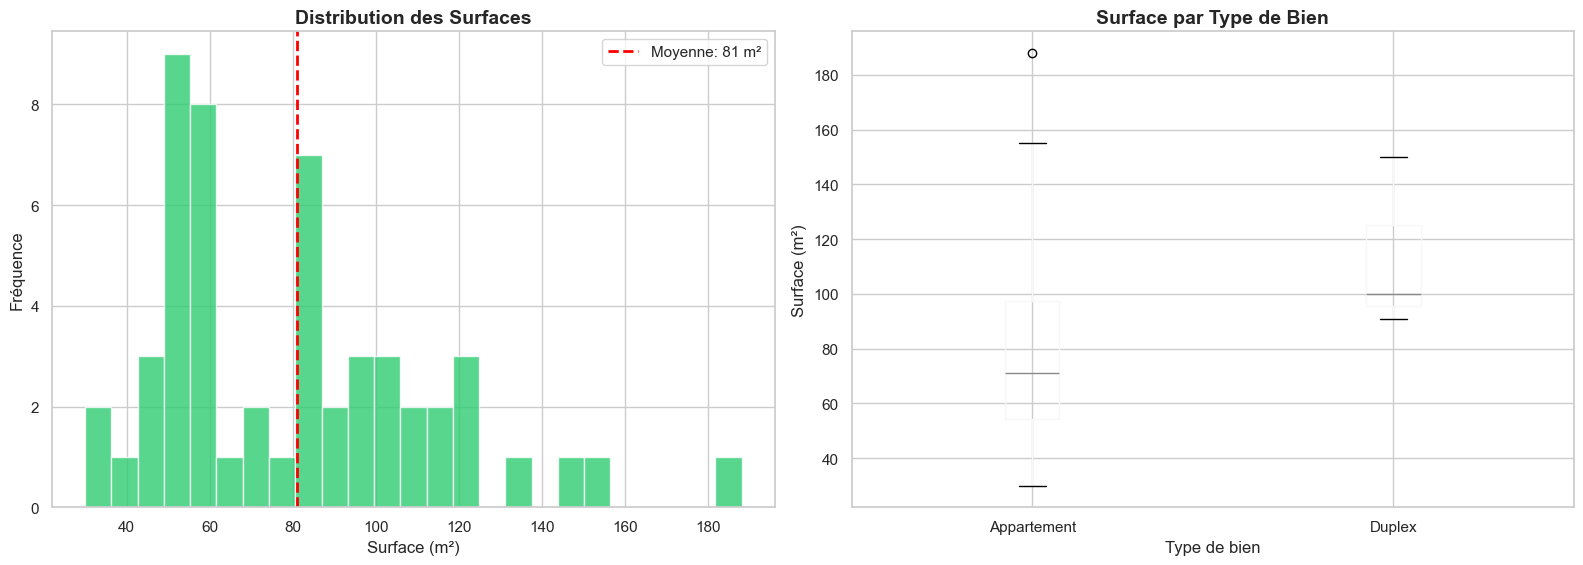

In [17]:
# Distribution des surfaces
df_surf = df[df['surface_m2'].notna()].copy()

if len(df_surf) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogramme surface
    axes[0].hist(df_surf['surface_m2'], bins=25, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[0].axvline(df_surf['surface_m2'].mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Moyenne: {df_surf["surface_m2"].mean():.0f} m²')
    axes[0].set_title('Distribution des Surfaces', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Surface (m²)')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()
    
    # Surface par type de bien
    df_surf.boxplot(column='surface_m2', by='type_bien', ax=axes[1])
    axes[1].set_title('Surface par Type de Bien', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Type de bien')
    axes[1].set_ylabel('Surface (m²)')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Aucune donnée de surface disponible')

## 10. 🔗 Corrélation Prix vs Surface

In [18]:
# Scatter plot Prix vs Surface
df_both = df[(df['prix'].notna()) & (df['surface_m2'].notna())].copy()

if len(df_both) > 2:
    fig = px.scatter(df_both, x='surface_m2', y='prix',
                     color='type_bien', size='score_equipements',
                     hover_data=['ville', 'source', 'prix_m2'],
                     title='Relation Prix vs Surface',
                     labels={'surface_m2': 'Surface (m²)', 'prix': 'Prix (MAD)', 
                             'type_bien': 'Type', 'score_equipements': 'Équipements'},
                     trendline='ols')
    fig.show()
    
    # Corrélation
    corr = df_both['prix'].corr(df_both['surface_m2'])
    print(f'📈 Corrélation Prix-Surface : {corr:.3f}')
else:
    print('⚠️ Pas assez de données avec prix ET surface pour l\'analyse de corrélation')

ModuleNotFoundError: No module named 'statsmodels'

## 11. 🛋️ Analyse des Équipements

In [ ]:
# Taux d'équipements
equipements = ['parking', 'ascenseur', 'balcon', 'piscine', 'jardin']
equip_taux = {eq: df[eq].mean() * 100 for eq in equipements if eq in df.columns}

fig, ax = plt.subplots(figsize=(10, 5))
colors_eq = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(equip_taux.keys(), equip_taux.values(), color=colors_eq, edgecolor='white')
ax.set_title('Taux d\'Équipements dans les Annonces', fontsize=16, fontweight='bold')
ax.set_ylabel('Pourcentage (%)')
ax.set_ylim(0, 100)

for bar, val in zip(bars, equip_taux.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Score moyen d'équipements
if 'score_equipements' in df.columns:
    print(f'\n📊 Score moyen d\'équipements : {df["score_equipements"].mean():.2f} / 5')

In [ ]:
# Impact des équipements sur le prix
if len(df_with_prix) > 0 and 'score_equipements' in df.columns:
    equip_prix = df_with_prix.groupby('score_equipements')['prix'].agg(['mean', 'count']).round(0)
    equip_prix.columns = ['Prix moyen (MAD)', 'Nb annonces']
    print('💰 Prix moyen par score d\'équipements :')
    display(equip_prix)
    
    fig = px.bar(equip_prix.reset_index(), x='score_equipements', y='Prix moyen (MAD)',
                 title='Impact des Équipements sur le Prix',
                 labels={'score_equipements': 'Score Équipements (0-5)'},
                 color='Prix moyen (MAD)', color_continuous_scale='YlOrRd')
    fig.show()

## 12. 🔥 Heatmap de Corrélation

In [ ]:
# Matrice de corrélation sur les variables numériques
numeric_cols = ['prix', 'surface_m2', 'prix_m2', 'parking', 'ascenseur', 
                'balcon', 'piscine', 'jardin', 'score_equipements']
numeric_cols_available = [c for c in numeric_cols if c in df.columns]

corr_matrix = df[numeric_cols_available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Matrice de Corrélation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. 📋 Résumé & Prochaines Étapes

In [ ]:
print('=' * 60)
print('📋 RÉSUMÉ DE L\'ANALYSE EXPLORATOIRE')
print('=' * 60)
print(f'\n📊 Dataset   : {len(df)} annonces de {nb_sources} sources')
print(f'📍 Couverture : {nb_villes} villes')
print(f'🏠 Types     : {df["type_bien"].nunique()} types de biens')

if pd.notna(prix_moyen):
    print(f'\n💰 Prix      : {prix_moyen:,.0f} MAD (moy) | {prix_median:,.0f} MAD (méd)')

if pd.notna(surface_moy):
    print(f'📐 Surface   : {surface_moy:.0f} m² (moy)')

if prix_m2_moy and pd.notna(prix_m2_moy):
    print(f'💵 Prix/m²   : {prix_m2_moy:,.0f} MAD/m² (moy)')

completeness_prix = df['prix'].notna().sum() / len(df) * 100
completeness_surf = df['surface_m2'].notna().sum() / len(df) * 100
print(f'\n📈 Complétude prix    : {completeness_prix:.0f}%')
print(f'📈 Complétude surface : {completeness_surf:.0f}%')

print('\n' + '=' * 60)
print('🎯 PROCHAINES ÉTAPES :')
print('=' * 60)
print('1. Corriger le sélecteur CSS d\'Avito pour récupérer les prix')
print('2. Scraper plus de pages pour enrichir le dataset')
print('3. Ajouter plus de villes (Casablanca, Rabat, Fès, etc.)')
print('4. Construire les modèles ML (prédiction prix)')
print('5. Créer le dashboard interactif')
print('=' * 60)